# Carga de conjunto de datos

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))
from typing import List, Tuple, Dict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from models import Autoencoder, SAE, CAE
from utils import get_device, train_val_test_split_scaled, print_summary_split

df = pd.read_csv("../data/breast-cancer-wisconsin.csv")
print(df.shape)

# Quitamos atributos no necesarios
df = df.drop(columns=["id", "Unnamed: 32"])

# Reemplazamos los valores en diagnosis por 0 y 1
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

# Dividimos nuestro conjuntos de datos y lo estandarizamos respecto a la división de entrenamiento. original: B = 357, M = 212
x_test, y_test, x_val, y_val, train_sets = train_val_test_split_scaled(df, "diagnosis")
etiquetas = ["A", "B", "C"]
x_val_norm = x_val[y_val==0]

# Desempaquetamos los conjuntos A, B y C
x_train_A, y_train_A = train_sets[0]  # 0% de anómalos
x_train_B, y_train_B = train_sets[1]  # 10% de anómalos
x_train_C, y_train_C = train_sets[2]  # 25% de anómalos

device = get_device()

print_summary_split([x_test, y_test, x_val, y_val, train_sets])

(569, 33)
Dispositivo usado: cuda (NVIDIA GeForce GTX 970)

     conjunto  proporcion  normales  anomalías  total
0        test         NaN        72         42    114
1  validacion         NaN        71         43    114
2       train        0.00       214          0    214
3       train        0.10       193         21    214
4       train        0.25       161         53    214


In [2]:
AE_A_PATH = "../models/Autoencoder_2025-12-11T00.13_lr=0.001_set=A.pth"
AE_B_PATH = "../models/Autoencoder_2025-12-11T00.14_lr=0.001_set=B.pth"
AE_C_PATH = "../models/Autoencoder_2025-12-11T00.14_lr=0.001_set=C.pth"

SAE_A_PATH = "../models/SAE_2025-12-10T23.33_lr=0.001_set=A.pth"
SAE_B_PATH = "../models/SAE_2025-12-10T23.33_lr=0.001_set=B.pth"
SAE_C_PATH = "../models/SAE_2025-12-10T23.33_lr=0.001_set=C.pth"

CAE_A_PATH = "../models/CAE_2025-12-11T12.30_lr=0.001_set=A.pth"
CAE_B_PATH = "../models/CAE_2025-12-11T12.32_lr=0.001_set=B.pth"
CAE_C_PATH = "../models/CAE_2025-12-11T12.32_lr=0.001_set=C.pth"

In [7]:
# Modelos Autoencoder
#"""
modelo_A = Autoencoder.load(path=AE_A_PATH, device=device)
modelo_B = Autoencoder.load(path=AE_B_PATH, device=device)
modelo_C = Autoencoder.load(path=AE_C_PATH, device=device)

modelo_A.summary()
#"""

<Autoencoder: In 30 → 32 → 16 → 8 → 4 → [2] → 4 → 8 → 16 → 32 → 30 Out>


c:\entornos-gpu\anomaly-detection-with-autoencoder\models.py:146: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(path, map_location=device)


In [4]:
# Modelos SAE
#"""
modelo_A = SAE.load(path=SAE_A_PATH, device=device)
modelo_B = SAE.load(path=SAE_B_PATH, device=device)
modelo_C = SAE.load(path=SAE_C_PATH, device=device)

modelo_A.summary()
#"""

<Autoencoder: In 30 → [64] → 30 Out>


In [5]:
# Modelos CAE
#"""
modelo_A = CAE.load(path=CAE_A_PATH, device=device)
modelo_B = CAE.load(path=CAE_B_PATH, device=device)
modelo_C = CAE.load(path=CAE_C_PATH, device=device)

modelo_A.summary()
#"""

<Autoencoder: In 30 → 32 → [16] → 32 → 30 Out>


# Histograma de errores de reconstrucción

Si se entrena un Autoencoder con un conjunto de datos $X$ (de entrenamiento) y luego se evalúa con un conjunto $T$ (de prueba) que sigue la misma distribución, se espera que:

$$
\lVert t'_1 - t_1 \rVert < \epsilon,
\qquad
t'_1 = \text{Decodificador}(\text{Codificador}(t_1)),
\qquad
t_1 \in T.
$$

El valor de $\epsilon$ (epsilon) se calcula de la siguiente manera:

$$
\epsilon =
\begin{cases}
\max(\lVert t'_i - t_i \rVert) & \text{si } \text{tipo\_epsilon} = 0, \\[6pt]
\operatorname{mean}(\lVert t'_i - t_i \rVert) & \text{si } \text{tipo\_epsilon} = 1, \\[6pt]
\operatorname{mean}(\lVert t'_i - t_i \rVert) + 2\,\operatorname{std}(\lVert t'_i - t_i \rVert) & \text{si } \text{tipo\_epsilon} = 2.
\end{cases}
$$


=== UMBRALES CALCULADOS ===
Media:               0.227
Media + 2 std:       0.665
Media + 3 std:       0.884
Percentil 95:        0.657
Youden:              0.446
=== UMBRALES CALCULADOS ===
Media:               0.304
Media + 2 std:       0.890
Media + 3 std:       1.183
Percentil 95:        0.953
Youden:              0.313
=== UMBRALES CALCULADOS ===
Media:               0.335
Media + 2 std:       0.983
Media + 3 std:       1.308
Percentil 95:        1.024
Youden:              0.334


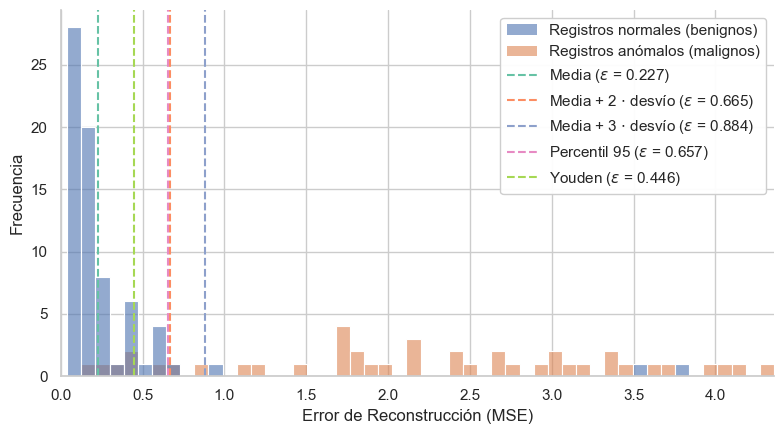

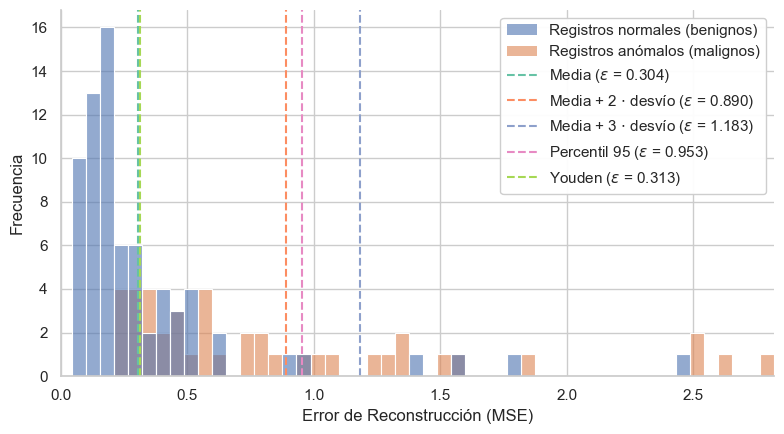

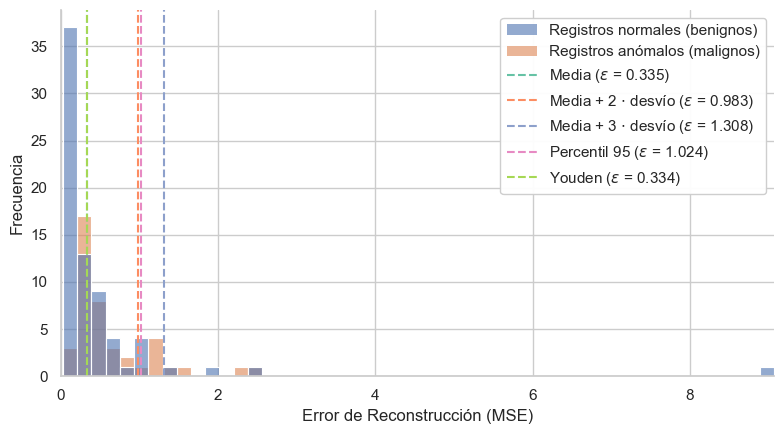

In [8]:
import matplotlib.patches as mpatches


def graficar_histograma_errores_reconstruccion(dif_norm, dif_anom, epsilons=None, bins=40, max_limit=None):
    sns.set_theme(style="whitegrid")
    data_norm = pd.DataFrame({"error": dif_norm, "clase": "Registros normales (benignos)"})
    data_anom  = pd.DataFrame({"error": dif_anom,  "clase": "Registros anómalos (malignos)"})
    data = pd.concat([data_norm, data_anom], ignore_index=True)

    plt.figure(figsize=(8, 4.5))
    ax = plt.gca()

    clases = list(data['clase'].unique())
    palette = sns.color_palette(n_colors=len(clases))

    sns.histplot(data=data, x="error", hue="clase", bins=bins, stat="count", common_norm=False, alpha=0.6, multiple="layer", palette=palette, ax=ax)

    if max_limit is not None:
        ax.set_xlim(0, max_limit)

    patches = []
    for i, clase in enumerate(clases):
        patch = mpatches.Patch(facecolor=palette[i], edgecolor='none', alpha=0.6, label=clase)
        patches.append(patch)

    line_handles = []
    if epsilons is not None:
        colores_umbrales = plt.cm.Set2.colors
        for i, (epsilon, nombre) in enumerate(epsilons):
            color = colores_umbrales[i % len(colores_umbrales)]
            line = ax.axvline(epsilon, color=color, linestyle='--', linewidth=1.5, label=f"{nombre} ($\\epsilon$ = {epsilon:.3f})")
            line_handles.append(line)

    all_handles = patches + line_handles
    all_labels = [h.get_label() for h in all_handles]

    ax.legend(handles=all_handles, labels=all_labels, frameon=True, fancybox=True,
              framealpha=0.95, loc='upper right')

    ax.set_xlabel("Error de Reconstrucción (MSE)")
    ax.set_ylabel("Frecuencia")
    sns.despine()
    plt.tight_layout()
    plt.show()

from utils import calculate_reconstruction_error, calculate_mean_std_threshold, calculate_percentil_n_threshold, calculate_youden_threshold

modelos = [modelo_A, modelo_B, modelo_C]
x_trains = [x_train_A, x_train_B, x_train_C]
nombres = ["A", "B", "C"]

errores = []
epsilons = []

METRIC_TYPE = "MSE" #"L1" "L2" "Linf" "MSE"

X = x_test
Y = y_test

for modelo in modelos:
    norm_errors = calculate_reconstruction_error(modelo, X[Y==0], device, metric_type=METRIC_TYPE)
    anom_errors = calculate_reconstruction_error(modelo, X[Y==1], device, metric_type=METRIC_TYPE)
    val_errors = calculate_reconstruction_error(modelo, x_val, device, metric_type=METRIC_TYPE)
    errores.append((norm_errors, anom_errors))

    eps_mean = calculate_mean_std_threshold(val_errors, y_val, 0)
    eps_mean_2std = calculate_mean_std_threshold(val_errors, y_val, 2)
    eps_mean_3std = calculate_mean_std_threshold(val_errors, y_val, 3)
    eps_p95 = calculate_percentil_n_threshold(val_errors, y_val, 95)
    eps_youden = calculate_youden_threshold(val_errors, y_val)

    print("=== UMBRALES CALCULADOS ===")
    print(f"{'Media:':20} {eps_mean:.3f}")
    print(f"{'Media + 2 std:':20} {eps_mean_2std:.3f}")
    print(f"{'Media + 3 std:':20} {eps_mean_3std:.3f}")
    print(f"{'Percentil 95:':20} {eps_p95:.3f}")
    print(f"{'Youden:':20} {eps_youden:.3f}")

    lista_eps = [
        (eps_mean, "Media"),
        (eps_mean_2std, "Media + 2 $\cdot$ desvío"),
        (eps_mean_3std, "Media + 3 $\cdot$ desvío"),
        (eps_p95, "Percentil 95"),
        (eps_youden, "Youden")
    ]
    epsilons.append(lista_eps)
for nombre, (norm_errors, anom_errors), lista_eps in zip(nombres, errores, epsilons):
    errors = np.concatenate([norm_errors, anom_errors])
    max_limit = np.percentile(errors, 100)
    graficar_histograma_errores_reconstruccion(
        dif_norm=norm_errors, 
        dif_anom=anom_errors, 
        epsilons=lista_eps, # Pasar la lista de umbrales
        bins=50, 
        max_limit=max_limit
    )

# Matriz de confusión y métricas

Luego las métricas se obtienen como:

$$
\begin{array}{rcl rcl}
\text{Accuracy} & = &
\dfrac{\text{TP} + \text{TN}}
      {\text{TP} + \text{FP} + \text{TN} + \text{FN}}
&
\text{Precision} & = &
\dfrac{\text{TP}}
      {\text{TP} + \text{FP}}
\\[14pt]

\text{Recall} & = &
\dfrac{\text{TP}}
      {\text{TP} + \text{FN}}
&
\text{Specificity} & = &
\dfrac{\text{TN}}
      {\text{TN} + \text{FP}}
\\[14pt]

\text{Balanced Accuracy} & = &
\dfrac{\dfrac{\text{TP}}{\text{TP}+\text{FN}} + \dfrac{\text{TN}}{\text{TN}+\text{FP}}}{2}
&
\text{F1\_Score} & = &
\dfrac{2\,\text{TP}}
      {2\,\text{TP} + \text{FP} + \text{FN}}
\end{array}
$$

Epsilon usado: Youden
[A] Matriz: TP=37, FN=5, TN=61, FP=11
{'accuracy': 0.86, 'precision': 0.771, 'recall': 0.881, 'specificity': 0.847, 'balanced_accuracy': 0.864, 'f1_score': 0.822}


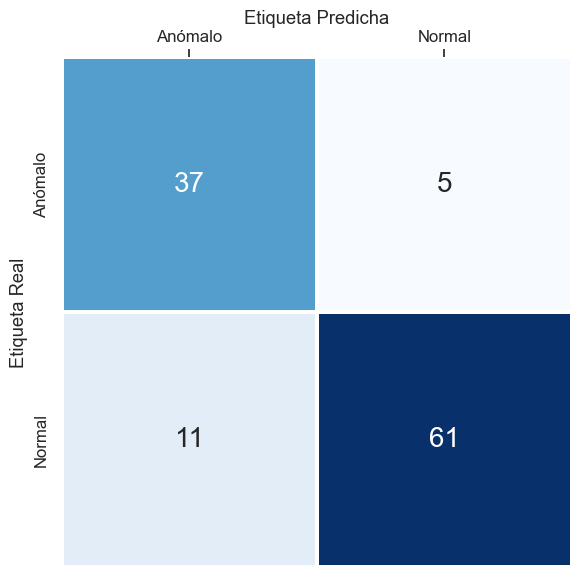

Epsilon usado: Youden
[B] Matriz: TP=34, FN=8, TN=51, FP=21
{'accuracy': 0.746, 'precision': 0.618, 'recall': 0.81, 'specificity': 0.708, 'balanced_accuracy': 0.759, 'f1_score': 0.701}


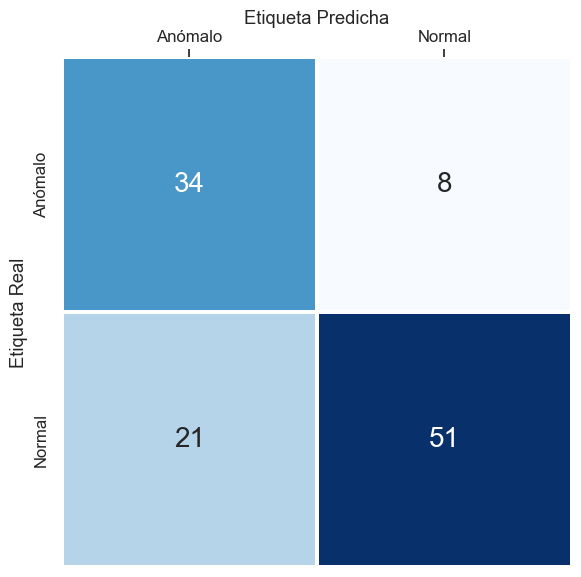

Epsilon usado: Youden
[C] Matriz: TP=26, FN=16, TN=46, FP=26
{'accuracy': 0.632, 'precision': 0.5, 'recall': 0.619, 'specificity': 0.639, 'balanced_accuracy': 0.629, 'f1_score': 0.553}


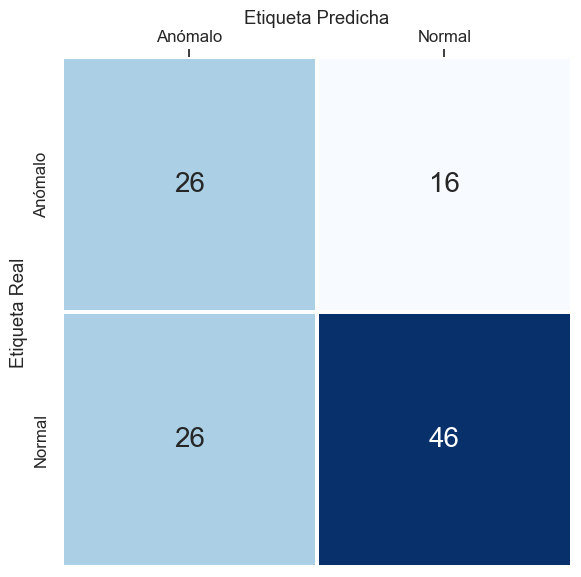

In [18]:
from utils import get_confusion_matrix, calculate_metrics

def graficar_matriz_confusion(TP: int, FN: int, TN: int, FP: int, norm: bool = False):
    
    matriz = np.array([[TP, FN], [FP, TN]])
    if norm: matriz = matriz / matriz.sum()
    
    sns.set_theme(style="white", context="notebook", font_scale=1.1)
    plt.figure(figsize=(6, 6))
    
    # Heatmap configurado en una sola línea fmt=".1%" para porcentaje
    ax = sns.heatmap(matriz, annot=True, fmt=".2f" if norm else "d", cmap="Blues", cbar=False, square=True, linewidths=1.5, linecolor='white',
                     xticklabels=["Anómalo", "Normal"], yticklabels=["Anómalo", "Normal"], annot_kws={"size": 20})
    
    # Mover etiquetas al tope
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    
    # Etiquetas de ejes limpias
    plt.ylabel("Etiqueta Real")
    plt.xlabel("Etiqueta Predicha")
    
    plt.tight_layout()
    plt.show()

for nombre, (norm_errors, anom_errors), lista_eps in zip(nombres, errores, epsilons):
    print(f"Epsilon usado: {lista_eps[-1][1]}")
    eps = lista_eps[-1][0]
    TP, FN, TN, FP = get_confusion_matrix(norm_errors, anom_errors, eps)
    print(f"[{nombre}] Matriz: TP={TP}, FN={FN}, TN={TN}, FP={FP}")
    print(calculate_metrics(TP, FN, TN, FP))
    graficar_matriz_confusion(TP, FN, TN, FP, False)

# Espacio latente

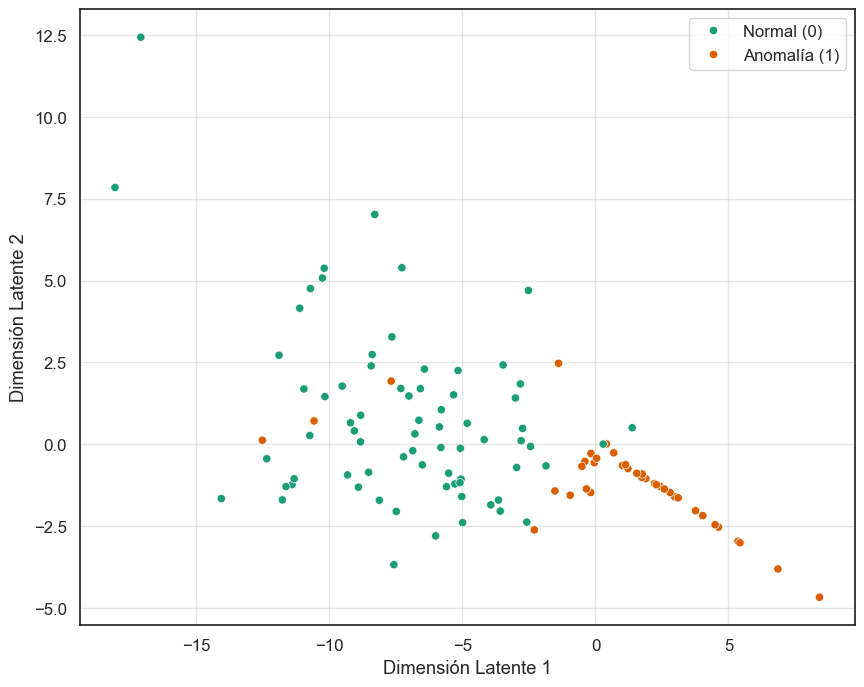

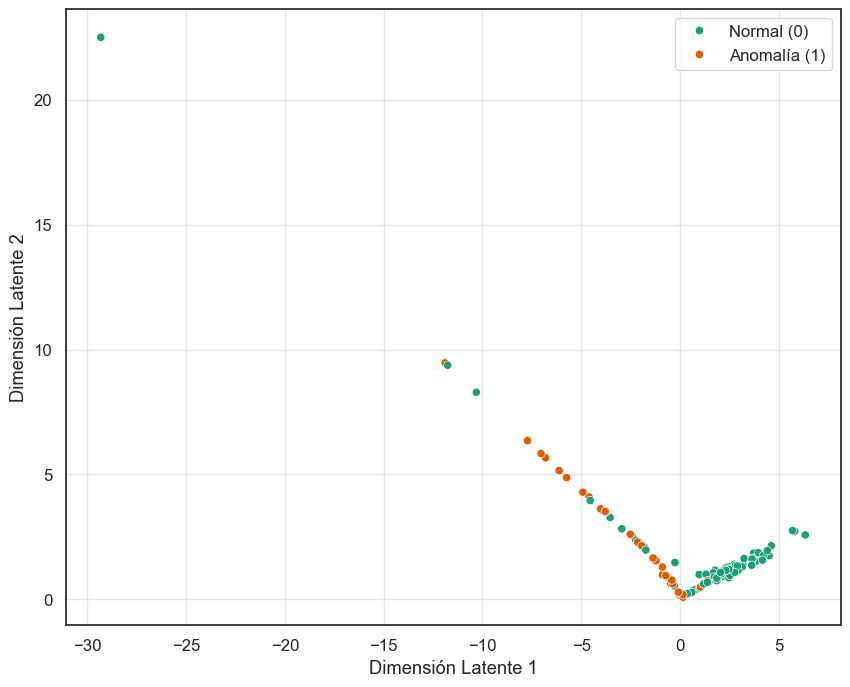

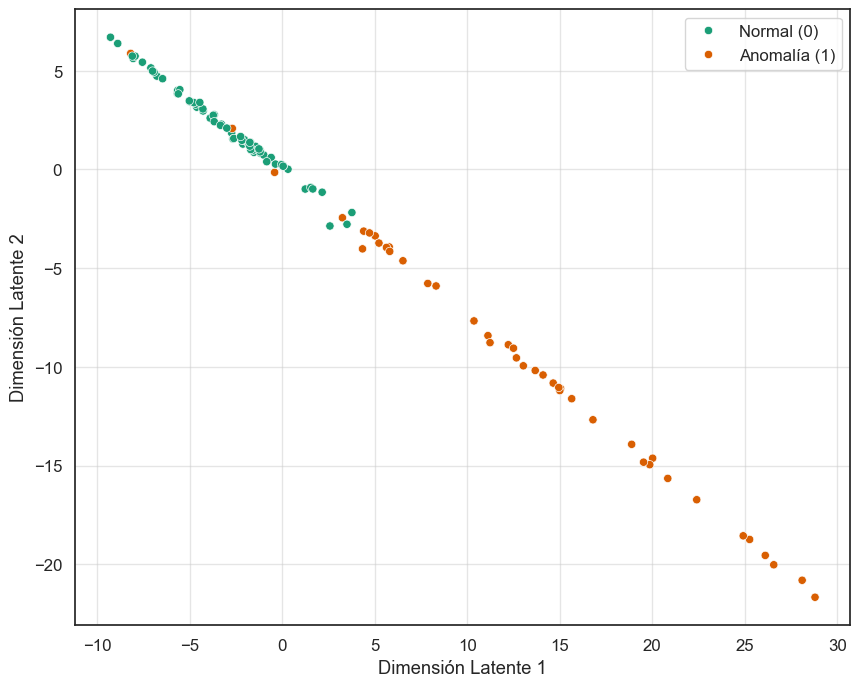

In [227]:
def graficar_espacio_latente(z: np.ndarray, y_labels: np.ndarray = None, target_names: List[str] = ["Clase 0", "Clase 1"]):
    latent_dim = z.shape[1]
    if latent_dim != 2:
        raise ValueError("Solo se puede graficar la capa latente si tiene dimensión 2.")
    
    df_plot = pd.DataFrame({'x': z[:, 0], 'y': z[:, 1]})
    
    if y_labels.size > 0:
        df_plot['clase'] = y_labels.astype(str)
        hue_param = 'clase'
        legend_param = "full"
    else:
        hue_param = None
        legend_param = False

    plt.figure(figsize=(10, 8))
    ax = sns.scatterplot(x='x', y='y', data=df_plot, hue=hue_param, palette="Dark2" ,legend=legend_param)

    if legend_param == "full":
        legend = ax.legend_
        legend.set_title("")
        
        for text, label in zip(legend.texts, target_names):
            text.set_text(label)

    plt.xlabel("Dimensión Latente 1")
    plt.ylabel("Dimensión Latente 2")
    plt.grid(True, alpha=0.5)
    plt.show()

z_A = modelo_A.encode(X, device)

graficar_espacio_latente(z_A, Y, ["Normal (0)", "Anomalía (1)"])

z_B = modelo_B.encode(X, device)

graficar_espacio_latente(z_B, Y, ["Normal (0)", "Anomalía (1)"])

z_C = modelo_C.encode(X, device)

graficar_espacio_latente(z_C, Y, ["Normal (0)", "Anomalía (1)"])

# Curva ROC y AUC

Hacer una curva ROC para cada conjunto (A, B y C)

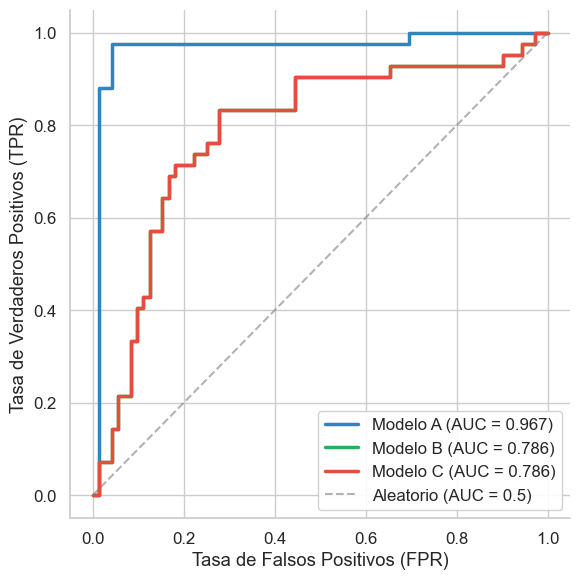

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

errores_A = calculate_reconstruction_error(modelo_A, X, device)
errores_B = calculate_reconstruction_error(modelo_B, X, device)
errores_C = calculate_reconstruction_error(modelo_C, X, device)

fpr_A, tpr_A, _ = roc_curve(Y, errores_A)
roc_auc_A = auc(fpr_A, tpr_A)

fpr_B, tpr_B, _ = roc_curve(Y, errores_B)
roc_auc_B = auc(fpr_B, tpr_B)

fpr_C, tpr_C, _ = roc_curve(Y, errores_C)
roc_auc_C = auc(fpr_C, tpr_C)

plt.figure(figsize=(6, 6))

colores = {'A': '#2E86C1', 'B': '#27AE60', 'C': '#E74C3C'}

plt.plot(fpr_A, tpr_A, color=colores['A'], lw=2.5, alpha=1, label=f'Modelo A (AUC = {roc_auc_A:.3f})')
plt.plot(fpr_B, tpr_B, color=colores['B'], lw=2.5, alpha=1, label=f'Modelo B (AUC = {roc_auc_B:.3f})')
plt.plot(fpr_C, tpr_C, color=colores['C'], lw=2.5, alpha=1, label=f'Modelo C (AUC = {roc_auc_C:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', alpha=0.6, label='Aleatorio (AUC = 0.5)')

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')

plt.legend(loc='lower right', frameon=True, fancybox=True, framealpha=0.9)

sns.despine()

plt.tight_layout()
plt.show()

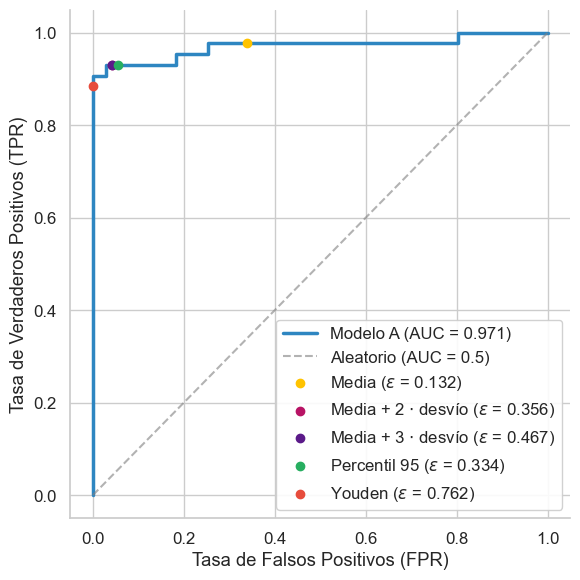

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

errores_A = calculate_reconstruction_error(modelo_A, x_val, device)

val_errors = calculate_reconstruction_error(modelo_A, x_val, device)
errores_norm_A = val_errors[y_val==0]
errores_anom_A = val_errors[y_val==1]

fpr_A, tpr_A, _ = roc_curve(y_val, errores_A)
roc_auc_A = auc(fpr_A, tpr_A)

# Umbral: Mean (Factor 0)
mean_thr = calculate_mean_std_threshold(val_errors, y_val, 0)
TP, FN, TN, FP = get_confusion_matrix(errores_norm_A, errores_anom_A, mean_thr)
metrics_mean = calculate_metrics(TP, FN, TN, FP)
mean_tpr, mean_fpr = metrics_mean["recall"], 1 - metrics_mean["specificity"]

# Umbral: Mean+2STD
m2std_thr = calculate_mean_std_threshold(val_errors, y_val, 2)
TP, FN, TN, FP = get_confusion_matrix(errores_norm_A, errores_anom_A, m2std_thr)
metrics_m2std = calculate_metrics(TP, FN, TN, FP)
m2std_tpr, m2std_fpr = metrics_m2std["recall"], 1 - metrics_m2std["specificity"]

# Umbral: Mean+3STD
m3std_thr = calculate_mean_std_threshold(val_errors, y_val, 3)
TP, FN, TN, FP = get_confusion_matrix(errores_norm_A, errores_anom_A, m2std_thr)
metrics_m3std = calculate_metrics(TP, FN, TN, FP)
m3std_tpr, m3std_fpr = metrics_m3std["recall"], 1 - metrics_m3std["specificity"]

# Umbral: Percentil 95
p95_thr = calculate_percentil_n_threshold(val_errors, y_val, 95)
TP, FN, TN, FP = get_confusion_matrix(errores_norm_A, errores_anom_A, p95_thr)
metrics_p95 = calculate_metrics(TP, FN, TN, FP)
p95_tpr, p95_fpr = metrics_p95["recall"], 1 - metrics_p95["specificity"]

# Umbral: Youden
youden_thr = calculate_youden_threshold(val_errors, y_val)
TP, FN, TN, FP = get_confusion_matrix(errores_norm_A, errores_anom_A, youden_thr)
metrics_youden = calculate_metrics(TP, FN, TN, FP)
youden_tpr, youden_fpr = metrics_youden["recall"], 1 - metrics_youden["specificity"]

plt.figure(figsize=(6, 6))

colores = {'A': '#2E86C1', 'B': '#27AE60', 'C': '#E74C3C'}

plt.plot(fpr_A, tpr_A, color=colores['A'], lw=2.5, alpha=1, label=f'Modelo A (AUC = {roc_auc_A:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', alpha=0.6, label='Aleatorio (AUC = 0.5)')

ZORDER_POINTS = 4

plt.scatter(mean_fpr, mean_tpr, color="#FFC300", label=f"Media ($\epsilon$ = {mean_thr:.3f})", zorder=ZORDER_POINTS)
plt.scatter(m2std_fpr, m2std_tpr, color="#B81365", label=f"Media + 2 $\cdot$ desvío ($\epsilon$ = {m2std_thr:.3f})", zorder=ZORDER_POINTS)
plt.scatter(m3std_fpr, m3std_tpr, color="#5B1A89", label=f"Media + 3 $\cdot$ desvío ($\epsilon$ = {m3std_thr:.3f})", zorder=ZORDER_POINTS)
plt.scatter(p95_fpr, p95_tpr, color="#27AE60", label=f"Percentil 95 ($\epsilon$ = {p95_thr:.3f})", zorder=ZORDER_POINTS)
plt.scatter(youden_fpr, youden_tpr, color="#E74C3C", label=f"Youden ($\epsilon$ = {youden_thr:.3f})", zorder=ZORDER_POINTS)

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')

plt.legend(loc='lower right', frameon=True, fancybox=True, framealpha=0.9)

sns.despine()

plt.tight_layout()
plt.show()

c:\entornos-gpu\anomaly-detection-with-autoencoder\models.py:146: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(path, map_location=device)


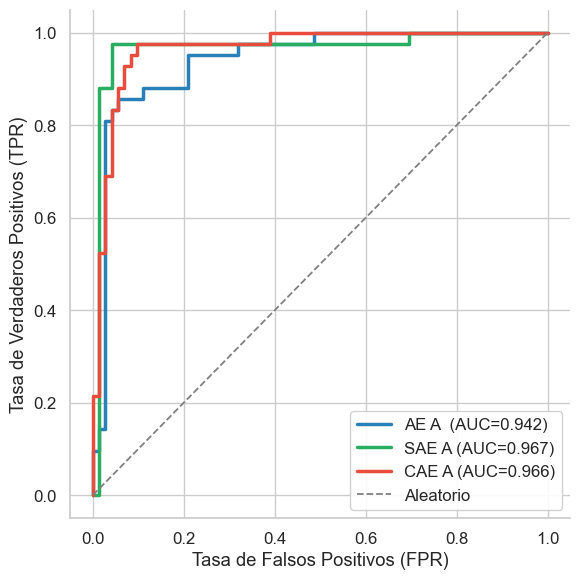

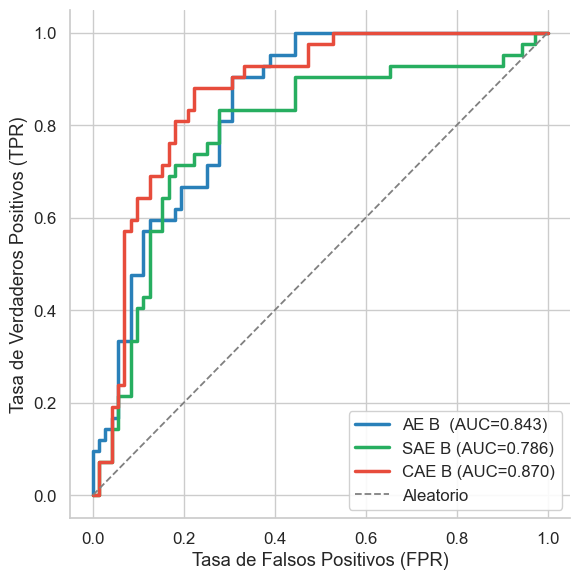

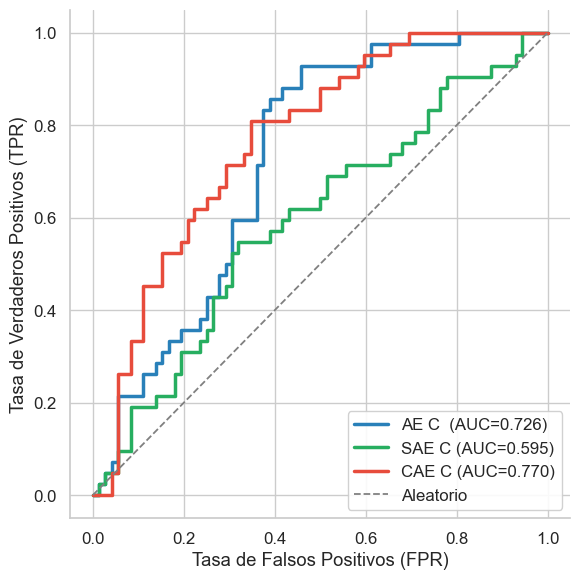

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

# ---- Modelos A (Set A) ----
ae_A = Autoencoder.load(path=AE_A_PATH, device=device)
sae_A = SAE.load(path=SAE_A_PATH, device=device)
cae_A = CAE.load(path=CAE_A_PATH, device=device)

# ---- Modelos B (Set B) ----
ae_B = Autoencoder.load(path=AE_B_PATH, device=device)
sae_B = SAE.load(path=SAE_B_PATH, device=device)
cae_B = CAE.load(path=CAE_B_PATH, device=device)

# ---- Modelos C (Set C) ----
ae_C = Autoencoder.load(path=AE_C_PATH, device=device)
sae_C = SAE.load(path=SAE_C_PATH, device=device)
cae_C = CAE.load(path=CAE_C_PATH, device=device)

colores = {
    "AE":  "#2980B9",
    "SAE": "#27AE60",
    "CAE": "#E74C3C"
}

def graficar_roc(model_AE, model_SAE, model_CAE, etiqueta):
    # Errores (puntajes)
    err_AE  = calculate_reconstruction_error(model_AE,  X, device)
    err_SAE = calculate_reconstruction_error(model_SAE, X, device)
    err_CAE = calculate_reconstruction_error(model_CAE, X, device)

    # ROC
    fpr_AE,  tpr_AE,  _ = roc_curve(Y, err_AE)
    fpr_SAE, tpr_SAE, _ = roc_curve(Y, err_SAE)
    fpr_CAE, tpr_CAE, _ = roc_curve(Y, err_CAE)

    auc_AE  = auc(fpr_AE,  tpr_AE)
    auc_SAE = auc(fpr_SAE, tpr_SAE)
    auc_CAE = auc(fpr_CAE, tpr_CAE)

    # --- Figura ---
    plt.figure(figsize=(6, 6))

    plt.plot(fpr_AE,  tpr_AE,  lw=2.5, color=colores["AE"], alpha=1,  label=f"AE {etiqueta}  (AUC={auc_AE:.3f})")
    plt.plot(fpr_SAE, tpr_SAE, lw=2.5, color=colores["SAE"], alpha=1, label=f"SAE {etiqueta} (AUC={auc_SAE:.3f})")
    plt.plot(fpr_CAE, tpr_CAE, lw=2.5, color=colores["CAE"], alpha=1, label=f"CAE {etiqueta} (AUC={auc_CAE:.3f})")

    plt.plot([0,1],[0,1], linestyle="--", color="gray", lw=1.3, label="Aleatorio")

    plt.xlabel('Tasa de Falsos Positivos (FPR)')
    plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
    plt.legend(loc="lower right", frameon=True, fancybox=True, framealpha=0.9)

    sns.despine()
    plt.tight_layout()
    plt.show()

graficar_roc(ae_A, sae_A, cae_A, "A")
graficar_roc(ae_B, sae_B, cae_B, "B")
graficar_roc(ae_C, sae_C, cae_C, "C")
